# Product & Category Profitability Analysis

### Objective

This notebook evaluates profitability at product and category level.

The analysis examines revenue, profit, profit margin, discounts, order
volume, and unit volume to identify high-performing products, high-revenue
but low-margin products, and categories with negative aggregate
profitability.

The analysis distinguishes revenue performance from profitability
performance so that products and categories are not evaluated solely
on sales volume.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load EDA dataset

DATA_PATH = "../data/processed/apl_logistics_eda.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 180,519
Columns: 42


## 1. Product and Category Validation

Before aggregating financial performance, product-category relationships
are checked to ensure that product-level results can be interpreted
consistently.

In [3]:
product_category_check = (
    df.groupby("Product Name")["Category Name"]
      .nunique()
)

print(
    "Products associated with multiple categories:",
    (product_category_check > 1).sum()
)

Products associated with multiple categories: 0


In [4]:
product_department_check = (
    df.groupby("Product Name")["Department Name"]
      .nunique()
)

print(
    "Products associated with multiple departments:",
    (product_department_check > 1).sum()
)

Products associated with multiple departments: 0


In [5]:
# Product level aggregation 

product_profitability = (
    df.groupby("Product Name")
      .agg(
          Category=("Category Name", "first"),
          Department=("Department Name", "first"),
          Orders=("Product Name", "count"),
          Units=("Order Item Quantity", "sum"),
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Discount=("Order Item Discount", "sum"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean"),
          Avg_Product_Price=("Product Price", "mean")
      )
      .reset_index()
)

In [6]:
print(
    f"Unique products: {len(product_profitability):,}"
)

Unique products: 118


In [7]:
# Product profit margin

product_profitability["Profit_Margin"] = (
    product_profitability["Profit"] /
    product_profitability["Sales"]
)

In [8]:
print(
    "Invalid product margins:",
    (~np.isfinite(
        product_profitability["Profit_Margin"]
    )).sum()
)

Invalid product margins: 0


In [9]:
# Product level summary statistics

product_profitability.describe()

,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Avg_Product_Price,Profit_Margin
count,118.00,118.00,118.00,118.00,118.00,118.00,118.00,118.00
mean,"1,529.82","3,254.91","311,735.04","33,617.82","31,613.38",0.10,166.41,0.11
std,"4,743.54","11,361.32","1,034,303.67","111,782.55","104,858.77",0.01,262.18,0.04
min,10.00,10.00,"3,059.59",-965.12,309.56,0.06,9.99,-0.04
25%,65.00,76.25,"12,649.45","1,216.14","1,294.40",0.10,31.99,0.09
50%,281.50,510.50,"20,582.35","2,396.99","2,109.03",0.10,87.19,0.11
75%,311.00,887.75,"40,659.53","3,959.12","4,053.63",0.10,199.99,0.13
max,"24,515.00","73,698.00","6,929,653.50","756,220.76","702,728.00",0.14,"1,999.99",0.20


In [10]:
# Top products by revenue

top_products_sales = (
    product_profitability
    .sort_values("Sales", ascending=False)
    .head(20)
)

top_products_sales[
    [
        "Product Name",
        "Category",
        "Orders",
        "Units",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
]

,Product Name,Category,Orders,Units,Sales,Profit,Profit_Margin
24,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,17325,17325,"6,929,653.50","756,220.76",0.11
71,Perfect Fitness Perfect Rip Deck,Cleats,24515,73698,"4,421,143.02","493,828.30",0.11
21,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,13729,13729,"4,118,425.42","427,455.57",0.10
61,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,12169,36680,"3,667,633.20","379,915.82",0.10
59,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel,21035,62956,"3,147,800.00","350,421.03",0.11
70,Pelican Sunstream 100 Kayak,Water Sports,15500,15500,"3,099,845.00","324,076.37",0.10
56,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,22246,22246,"2,891,757.54","311,902.82",0.11
67,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,19298,57803,"2,888,993.94","318,451.43",0.11
102,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport,10617,31735,"1,269,082.65","126,278.51",0.10
18,Dell Laptop,Computers,442,442,"663,000.00","69,656.81",0.11


In [11]:
# Top products by profit

top_products_profit = (
    product_profitability
    .sort_values("Profit", ascending=False)
    .head(20)
)

top_products_profit[
    [
        "Product Name",
        "Category",
        "Orders",
        "Units",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
]

,Product Name,Category,Orders,Units,Sales,Profit,Profit_Margin
24,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,17325,17325,"6,929,653.50","756,220.76",0.11
71,Perfect Fitness Perfect Rip Deck,Cleats,24515,73698,"4,421,143.02","493,828.30",0.11
21,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,13729,13729,"4,118,425.42","427,455.57",0.10
61,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,12169,36680,"3,667,633.20","379,915.82",0.10
59,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel,21035,62956,"3,147,800.00","350,421.03",0.11
70,Pelican Sunstream 100 Kayak,Water Sports,15500,15500,"3,099,845.00","324,076.37",0.10
67,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,19298,57803,"2,888,993.94","318,451.43",0.11
56,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,22246,22246,"2,891,757.54","311,902.82",0.11
102,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport,10617,31735,"1,269,082.65","126,278.51",0.10
18,Dell Laptop,Computers,442,442,"663,000.00","69,656.81",0.11


In [12]:
# High revenue/ low-margin products 

product_sales_median = product_profitability["Sales"].median()
product_margin_median = product_profitability["Profit_Margin"].median()

print(
    f"Product sales median: {product_sales_median:,.2f}"
)

print(
    f"Product margin median: {product_margin_median:.2%}"
)

Product sales median: 20,582.35
Product margin median: 11.00%


In [13]:
high_revenue_low_margin_products = product_profitability[
    (product_profitability["Sales"] >= product_sales_median) &
    (product_profitability["Profit_Margin"] < product_margin_median)
].copy()

In [14]:
high_revenue_low_margin_products = (
    high_revenue_low_margin_products
    .sort_values("Sales", ascending=False)
)

high_revenue_low_margin_products[
    [
        "Product Name",
        "Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].head(20)

,Product Name,Category,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
24,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,"6,929,653.50","756,220.76",0.11,"702,728.00",0.10
21,Diamondback Women's Serene Classic Comfort Bi,Camping & Hiking,"4,118,425.42","427,455.57",0.10,"417,649.50",0.10
61,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,"3,667,633.20","379,915.82",0.10,"371,942.59",0.10
70,Pelican Sunstream 100 Kayak,Water Sports,"3,099,845.00","324,076.37",0.10,"314,327.00",0.10
56,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,"2,891,757.54","311,902.82",0.11,"293,263.10",0.10
102,Under Armour Girls' Toddler Spine Surge Runni,Shop By Sport,"1,269,082.65","126,278.51",0.10,"128,314.03",0.10
18,Dell Laptop,Computers,"663,000.00","69,656.81",0.11,"67,605.00",0.10
78,Smart watch,Sporting Goods,"117,006.75","12,518.61",0.11,"11,943.73",0.10
26,First aid kit,Health and Beauty,"106,080.48","9,493.63",0.09,"10,722.37",0.10
17,DVDs,DVDs,"79,395.54","6,655.43",0.08,"8,076.43",0.10


In [15]:
# Loss making products 

loss_making_products = product_profitability[
    product_profitability["Profit"] < 0
].copy()

print(
    f"Loss-making products: {len(loss_making_products):,}"
)

Loss-making products: 3


In [16]:
loss_making_products[
    [
        "Product Name",
        "Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].sort_values(
    "Profit"
).head(20)

,Product Name,Category,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
77,SOLE E35 Elliptical,Strength Training,"29,999.85",-965.12,-0.03,"3,590.00",0.12
9,Bushnell Pro X7 Jolt Slope Rangefinder,Kids' Golf Clubs,"6,599.89",-255.95,-0.04,537.00,0.08
76,SOLE E25 Elliptical,Basketball,"9,999.90",-169.56,-0.02,585.00,0.06


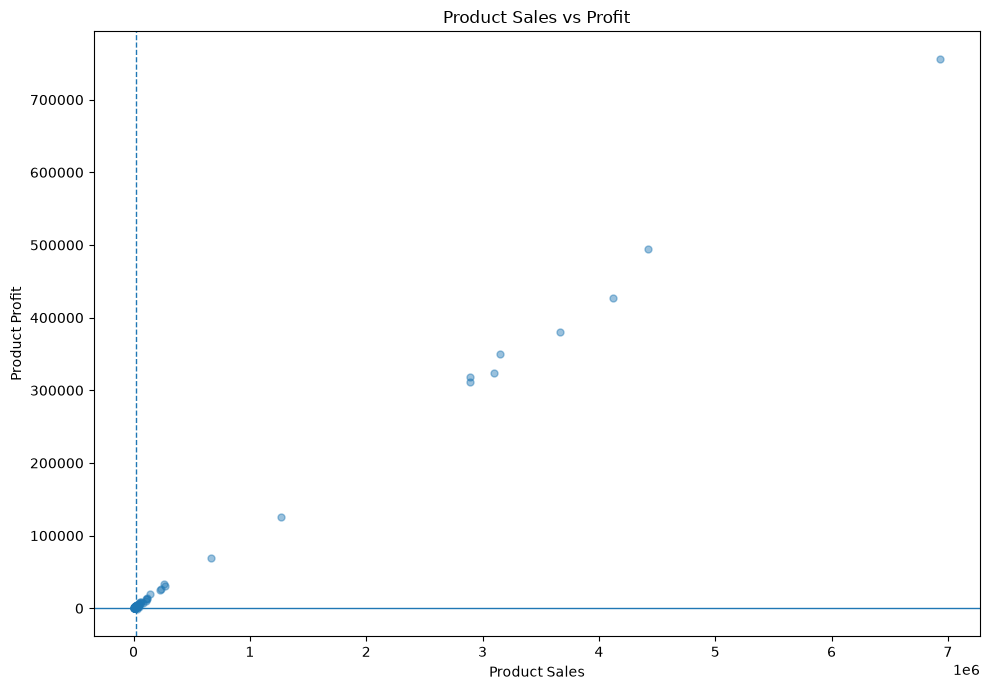

In [17]:
# Product sales vs profit

plt.figure(figsize=(10, 7))

plt.scatter(
    product_profitability["Sales"],
    product_profitability["Profit"],
    alpha=0.45,
    s=25
)

plt.axhline(
    0,
    linewidth=1
)

plt.axvline(
    product_sales_median,
    linestyle="--",
    linewidth=1
)

plt.title("Product Sales vs Profit")
plt.xlabel("Product Sales")
plt.ylabel("Product Profit")

plt.tight_layout()
plt.show()

In [18]:
# Category level aggregation 

category_profitability = (
    df.groupby("Category Name")
      .agg(
          Products=("Product Name", "nunique"),
          Orders=("Product Name", "count"),
          Units=("Order Item Quantity", "sum"),
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Discount=("Order Item Discount", "sum"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean")
      )
      .reset_index()
)

In [19]:
category_profitability["Profit_Margin"] = (
    category_profitability["Profit"] /
    category_profitability["Sales"]
)

In [20]:
# Category financial performance

category_profitability.sort_values(
    "Profit",
    ascending=False
)

,Category Name,Products,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Profit_Margin
18,Fishing,1,17325,17325,"6,929,653.50","756,220.76","702,728.00",0.10,0.11
12,Cleats,2,24551,73734,"4,431,942.66","494,636.92","449,091.67",0.10,0.11
9,Camping & Hiking,1,13729,13729,"4,118,425.42","427,455.57","417,649.50",0.10,0.10
10,Cardio Equipment,2,12487,37587,"3,694,843.20","383,011.10","374,595.19",0.10,0.10
47,Women's Apparel,1,21035,62956,"3,147,800.00","350,421.03","319,091.50",0.10,0.11
46,Water Sports,2,15540,15540,"3,113,844.60","325,146.96","315,800.50",0.10,0.10
30,Indoor/Outdoor Games,1,19298,57803,"2,888,993.94","318,451.43","292,550.63",0.10,0.11
34,Men's Footwear,1,22246,22246,"2,891,757.54","311,902.82","293,263.10",0.10,0.11
38,Shop By Sport,3,10984,32726,"1,309,522.02","129,813.96","132,338.73",0.10,0.10
13,Computers,1,442,442,"663,000.00","69,656.81","67,605.00",0.10,0.11


In [21]:
category_profitability[
    [
        "Category Name",
        "Products",
        "Orders",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount"
    ]
].sort_values(
    "Profit",
    ascending=False
)

,Category Name,Products,Orders,Sales,Profit,Profit_Margin,Discount
18,Fishing,1,17325,"6,929,653.50","756,220.76",0.11,"702,728.00"
12,Cleats,2,24551,"4,431,942.66","494,636.92",0.11,"449,091.67"
9,Camping & Hiking,1,13729,"4,118,425.42","427,455.57",0.10,"417,649.50"
10,Cardio Equipment,2,12487,"3,694,843.20","383,011.10",0.10,"374,595.19"
47,Women's Apparel,1,21035,"3,147,800.00","350,421.03",0.11,"319,091.50"
46,Water Sports,2,15540,"3,113,844.60","325,146.96",0.10,"315,800.50"
30,Indoor/Outdoor Games,1,19298,"2,888,993.94","318,451.43",0.11,"292,550.63"
34,Men's Footwear,1,22246,"2,891,757.54","311,902.82",0.11,"293,263.10"
38,Shop By Sport,3,10984,"1,309,522.02","129,813.96",0.10,"132,338.73"
13,Computers,1,442,"663,000.00","69,656.81",0.11,"67,605.00"


In [22]:
# Top categories by revenue 

category_profitability[
    [
        "Category Name",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
].sort_values(
    "Sales",
    ascending=False
).head(15)

,Category Name,Sales,Profit,Profit_Margin
18,Fishing,"6,929,653.50","756,220.76",0.11
12,Cleats,"4,431,942.66","494,636.92",0.11
9,Camping & Hiking,"4,118,425.42","427,455.57",0.10
10,Cardio Equipment,"3,694,843.20","383,011.10",0.10
47,Women's Apparel,"3,147,800.00","350,421.03",0.11
46,Water Sports,"3,113,844.60","325,146.96",0.10
34,Men's Footwear,"2,891,757.54","311,902.82",0.11
30,Indoor/Outdoor Games,"2,888,993.94","318,451.43",0.11
38,Shop By Sport,"1,309,522.02","129,813.96",0.10
13,Computers,"663,000.00","69,656.81",0.11


In [23]:
category_profitability[
    [
        "Category Name",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
].sort_values(
    "Profit",
    ascending=False
).head(15)

,Category Name,Sales,Profit,Profit_Margin
18,Fishing,"6,929,653.50","756,220.76",0.11
12,Cleats,"4,431,942.66","494,636.92",0.11
9,Camping & Hiking,"4,118,425.42","427,455.57",0.10
10,Cardio Equipment,"3,694,843.20","383,011.10",0.10
47,Women's Apparel,"3,147,800.00","350,421.03",0.11
46,Water Sports,"3,113,844.60","325,146.96",0.10
30,Indoor/Outdoor Games,"2,888,993.94","318,451.43",0.11
34,Men's Footwear,"2,891,757.54","311,902.82",0.11
38,Shop By Sport,"1,309,522.02","129,813.96",0.10
13,Computers,"663,000.00","69,656.81",0.11


In [24]:
# Loss making categories

loss_making_categories = category_profitability[
    category_profitability["Profit"] < 0
].copy()

print(
    f"Loss-making categories: "
    f"{len(loss_making_categories):,}"
)

Loss-making categories: 0


In [25]:
loss_making_categories[
    [
        "Category Name",
        "Products",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount"
    ]
].sort_values(
    "Profit"
)

,Category Name,Products,Sales,Profit,Profit_Margin,Discount


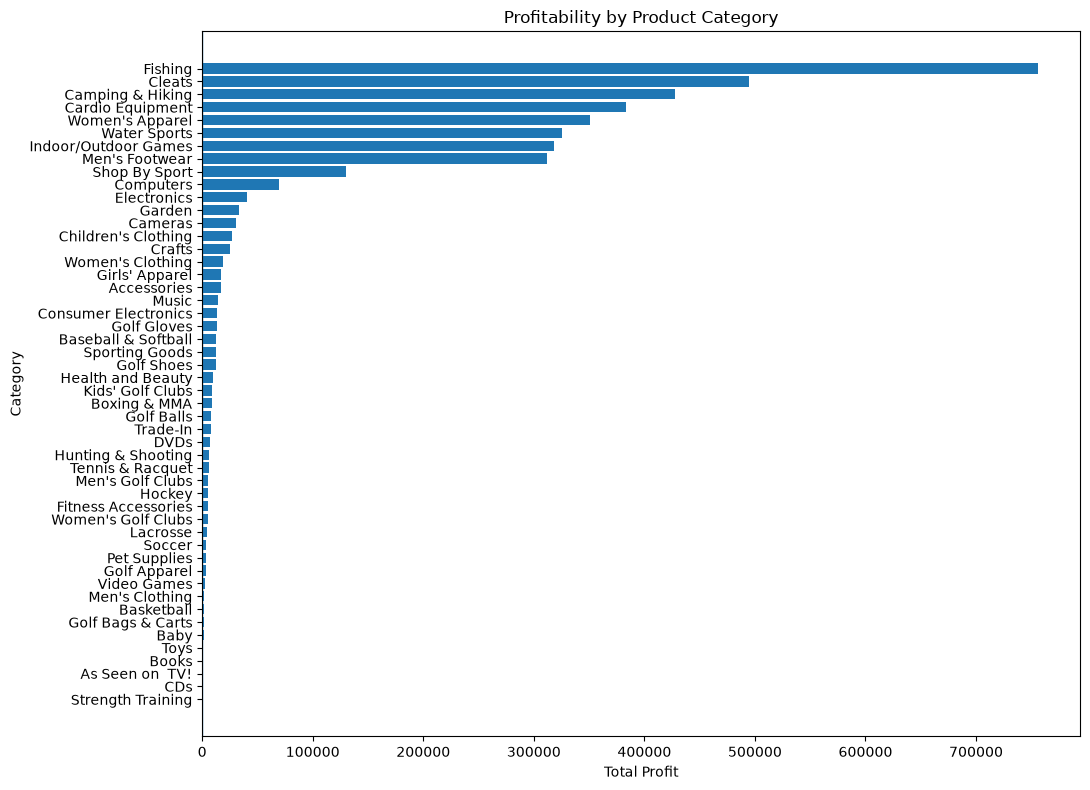

In [26]:
# Category profitability chart

category_plot = (
    category_profitability
    .sort_values("Profit")
)

plt.figure(figsize=(11, 8))

plt.barh(
    category_plot["Category Name"],
    category_plot["Profit"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("Profitability by Product Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

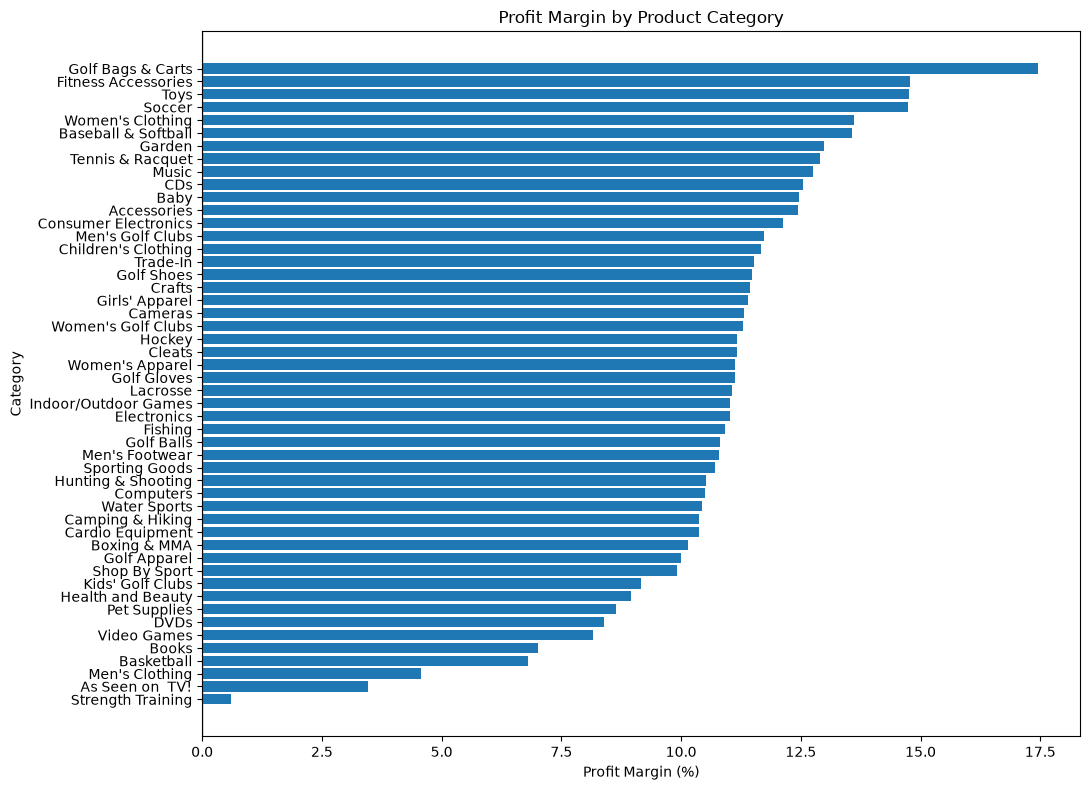

In [27]:
# Category margin chart

category_margin_plot = (
    category_profitability
    .sort_values("Profit_Margin")
)

plt.figure(figsize=(11, 8))

plt.barh(
    category_margin_plot["Category Name"],
    category_margin_plot["Profit_Margin"] * 100
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

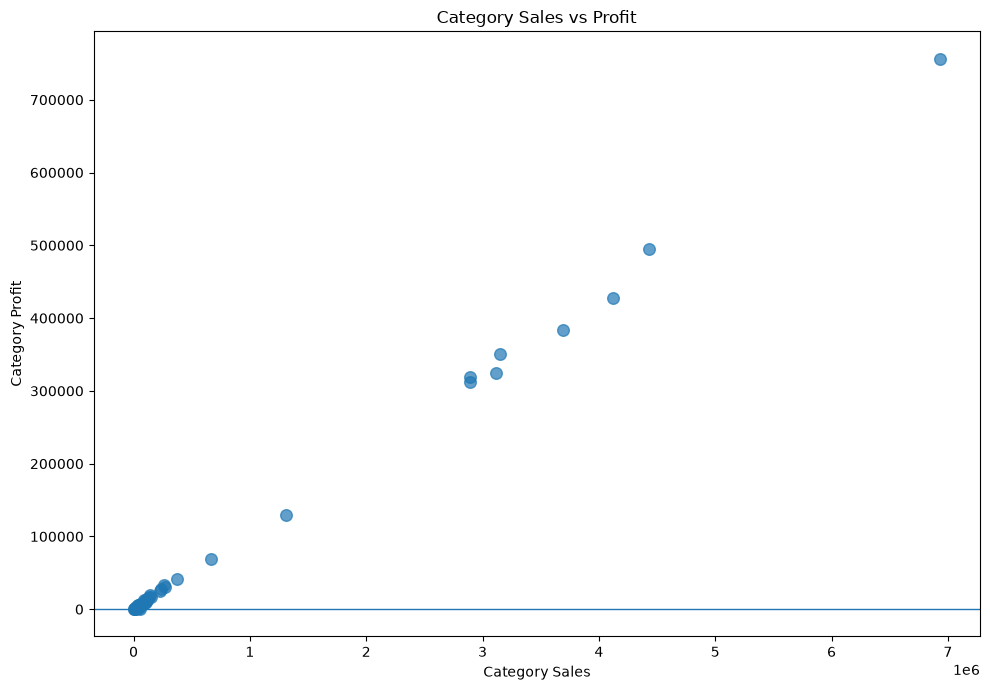

In [28]:
# Category sales vs profit

plt.figure(figsize=(10, 7))

plt.scatter(
    category_profitability["Sales"],
    category_profitability["Profit"],
    s=70,
    alpha=0.7
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Category Sales vs Profit")
plt.xlabel("Category Sales")
plt.ylabel("Category Profit")

plt.tight_layout()
plt.show()

In [29]:
# Category level discount diagnostic

category_discount_correlation = (
    category_profitability[
        [
            "Avg_Discount_Rate",
            "Profit_Margin"
        ]
    ]
    .corr()
)

category_discount_correlation

,Avg_Discount_Rate,Profit_Margin
Avg_Discount_Rate,1.00,-0.45
Profit_Margin,-0.45,1.00


In [30]:
# Save the product dataset

product_path = (
    "../data/processed/product_profitability.csv"
)

product_profitability.to_csv(
    product_path,
    index=False
)

print(
    f"Saved: {product_path}"
)

Saved: ../data/processed/product_profitability.csv


In [31]:
# Save the category dataset

category_path = (
    "../data/processed/category_profitability.csv"
)

category_profitability.to_csv(
    category_path,
    index=False
)

print(
    f"Saved: {category_path}"
)

Saved: ../data/processed/category_profitability.csv
